In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [2]:
SHARED_DATASET_FILE = "../data/processed/cleaned_emotions_shared.csv"
SHARED_SPLIT_FILE   = "../data/splits/shared_split.json"

MODEL_NAME     = "emilyalsentzer/Bio_ClinicalBERT"
MODEL_SAVE_DIR = "../models/clinicalbert_model"
PRED_FILE      = "../data/processed/clinicalbert_test_predictions.csv"
SUMMARY_FILE   = "../data/processed/clinicalbert_summary.csv"
DISPLAY_NAME   = "ClinicalBERT"

MAX_LEN    = 64
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5
PATIENCE   = 2

LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

total_start_time = time.time()

Using device: cuda


### Load Data

In [3]:
df = pd.read_csv(SHARED_DATASET_FILE)

with open(SHARED_SPLIT_FILE, "r", encoding="utf-8") as f:
    split_dict = json.load(f)

train_df = df[df["row_id"].isin(split_dict["train_ids"])].copy()
val_df   = df[df["row_id"].isin(split_dict["val_ids"])].copy()
test_df  = df[df["row_id"].isin(split_dict["test_ids"])].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

Train: (1512, 3)
Val  : (324, 3)
Test : (324, 3)

Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64


### Label Encoding

In [4]:
label_encoder = LabelEncoder()
label_encoder.fit(LABELS)

y_train = label_encoder.transform(train_df["label"])
y_val   = label_encoder.transform(val_df["label"])
y_test  = label_encoder.transform(test_df["label"])

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Number of classes: 6


### Tokenizer & Dataset

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(train_df["text"].tolist(), y_train, tokenizer, MAX_LEN)
val_dataset   = EmotionDataset(val_df["text"].tolist(),   y_val,   tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(test_df["text"].tolist(),  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--emilyalsentzer--Bio_ClinicalBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Train batches : 95
Val batches   : 21
Test batches  : 21


### Model

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes)
model = model.to(device)
print(f"Model   : {MODEL_NAME}")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23243.94it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISS

Model   : emilyalsentzer/Bio_ClinicalBERT
Params  : 108,314,886


### Train

In [7]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss    = float("inf")
patience_counter = 0

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc = eval_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS}  |  Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        model.save_pretrained(MODEL_SAVE_DIR)
        tokenizer.save_pretrained(MODEL_SAVE_DIR)
        print("  -> Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

train_elapsed = time.time() - train_start
print(f"\nTraining time: {train_elapsed:.2f} seconds")

Epoch 1/5  |  Train Loss: 1.5141  Acc: 0.4292  |  Val Loss: 0.9419  Acc: 0.7685


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.86it/s]


  -> Best model saved
Epoch 2/5  |  Train Loss: 0.6151  Acc: 0.8519  |  Val Loss: 0.3497  Acc: 0.9012


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.83s/it]


  -> Best model saved
Epoch 3/5  |  Train Loss: 0.2489  Acc: 0.9431  |  Val Loss: 0.2420  Acc: 0.9290


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.68it/s]


  -> Best model saved
Epoch 4/5  |  Train Loss: 0.1338  Acc: 0.9663  |  Val Loss: 0.2508  Acc: 0.9198
Epoch 5/5  |  Train Loss: 0.0776  Acc: 0.9868  |  Val Loss: 0.2620  Acc: 0.9198

Early stopping at epoch 5

Training time: 47.23 seconds


### Evaluate

In [8]:
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
best_model = best_model.to(device)
best_model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        preds   = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs        = np.array(all_probs)
test_pred_labels = label_encoder.inverse_transform(all_preds)
test_true_labels = label_encoder.inverse_transform(y_test)

acc               = accuracy_score(test_true_labels, test_pred_labels)
f1_macro          = f1_score(test_true_labels, test_pred_labels, average="macro")
f1_weighted       = f1_score(test_true_labels, test_pred_labels, average="weighted")
precision_macro   = precision_score(test_true_labels, test_pred_labels, average="macro",    zero_division=0)
precision_weighted = precision_score(test_true_labels, test_pred_labels, average="weighted", zero_division=0)

print(f"\n===== {DISPLAY_NAME} RESULT =====")
print("Accuracy          :", acc)
print("F1 Macro          :", f1_macro)
print("F1 Weighted       :", f1_weighted)
print("Precision Macro   :", precision_macro)
print("Precision Weighted:", precision_weighted)
print("\nClassification Report:")
print(classification_report(test_true_labels, test_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(test_true_labels, test_pred_labels, labels=LABELS))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6538.50it/s]



===== ClinicalBERT RESULT =====
Accuracy          : 0.9074074074074074
F1 Macro          : 0.9181348987472253
F1 Weighted       : 0.9063929414126755
Precision Macro   : 0.9142528753185754
Precision Weighted: 0.9069558609285036

Classification Report:
              precision    recall  f1-score   support

       angry       0.94      1.00      0.97        49
     disgust       0.92      0.86      0.89        64
        fear       0.84      0.82      0.83        60
       happy       1.00      1.00      1.00        35
     neutral       0.89      0.87      0.88        75
         sad       0.89      1.00      0.94        41

    accuracy                           0.91       324
   macro avg       0.91      0.92      0.92       324
weighted avg       0.91      0.91      0.91       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 1 55  4  0  0  4]
 [ 0  3 49  0  8  0]
 [ 0  0  0 35  0  0]
 [ 2  2  5  0 65  1]
 [ 0  0  0  0  0 41]]


### Save

In [9]:
pred_col       = f"{DISPLAY_NAME.lower()}_pred"
confidence_col = f"{DISPLAY_NAME.lower()}_confidence"

pred_df = test_df[["row_id", "text", "label"]].copy().reset_index(drop=True)
pred_df[pred_col]       = test_pred_labels
pred_df[confidence_col] = all_probs.max(axis=1)
pred_df.to_csv(PRED_FILE, index=False, encoding="utf-8-sig")

summary_df = pd.DataFrame([{
    "Model":              DISPLAY_NAME,
    "Accuracy":           acc,
    "F1_Macro":           f1_macro,
    "F1_Weighted":        f1_weighted,
    "Train_Time_Seconds": round(train_elapsed, 4),
    "Num_Classes":        num_classes
}])
summary_df.to_csv(SUMMARY_FILE, index=False, encoding="utf-8-sig")

total_elapsed = time.time() - total_start_time

print("\n===== Summary =====")
print(summary_df)
print(f"\nSaved:")
print("-", PRED_FILE)
print("-", SUMMARY_FILE)
print(f"\nTotal {DISPLAY_NAME} pipeline time: {total_elapsed:.2f} seconds")
print("Done")


===== Summary =====
          Model  Accuracy  F1_Macro  F1_Weighted  Train_Time_Seconds  \
0  ClinicalBERT  0.907407  0.918135     0.906393             47.2279   

   Num_Classes  
0            6  

Saved:
- ../data/processed/clinicalbert_test_predictions.csv
- ../data/processed/clinicalbert_summary.csv

Total ClinicalBERT pipeline time: 61.31 seconds
Done


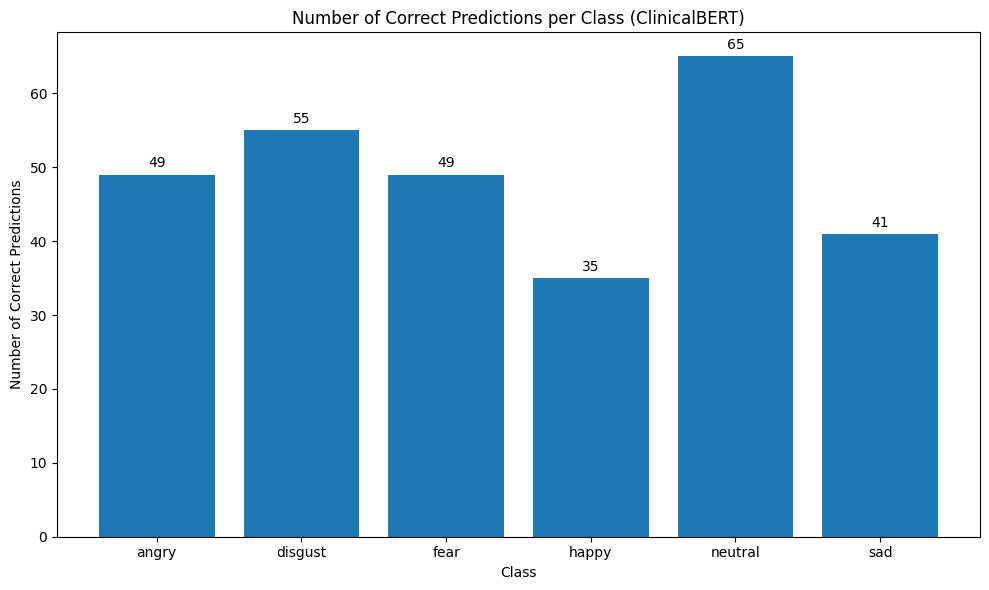

In [10]:
correct_counts = []
for label in LABELS:
    count = ((pred_df["label"] == label) & (pred_df[pred_col] == label)).sum()
    correct_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(LABELS, correct_counts, label=DISPLAY_NAME)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Correct Predictions")
ax.set_title(f"Number of Correct Predictions per Class ({DISPLAY_NAME})")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()


ClinicalBERT Confusion Matrix


,angry,disgust,fear,happy,neutral,sad
angry,49,0,0,0,0,0
disgust,1,55,4,0,0,4
fear,0,3,49,0,8,0
happy,0,0,0,35,0,0
neutral,2,2,5,0,65,1
sad,0,0,0,0,0,41


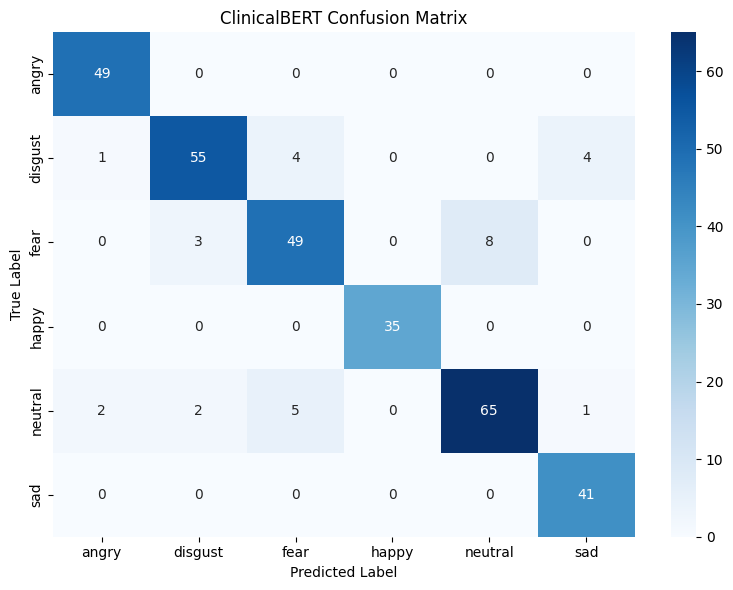

In [11]:
cm    = confusion_matrix(pred_df["label"], pred_df[pred_col], labels=LABELS)
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

print("\n" + "=" * 60)
print(f"{DISPLAY_NAME} Confusion Matrix")
print("=" * 60)
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"{DISPLAY_NAME} Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

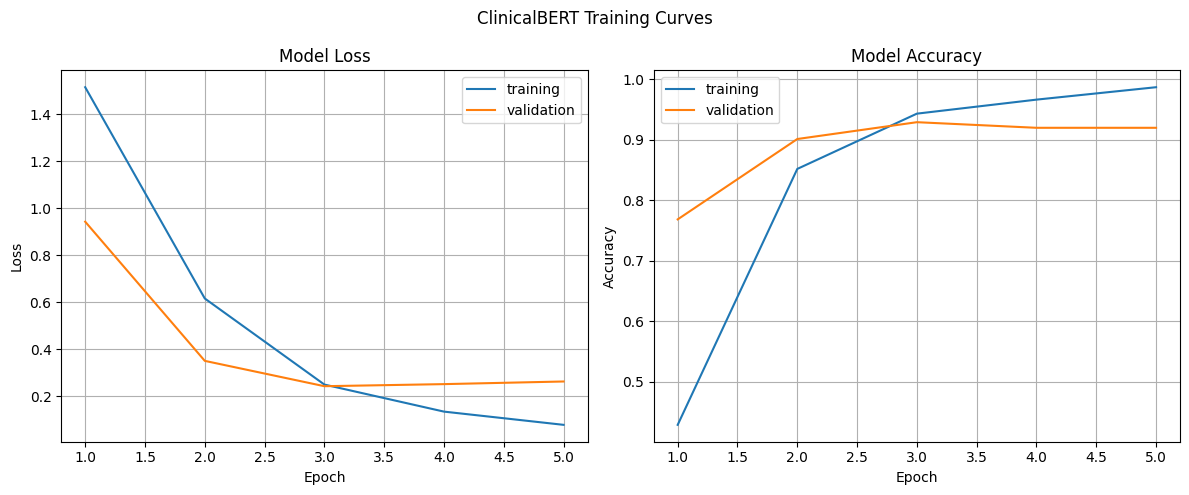

In [12]:
train_loss   = history["train_loss"]
val_loss     = history["val_loss"]
train_acc    = history["train_acc"]
val_acc      = history["val_acc"]
epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, train_loss, label="training")
axes[0].plot(epochs_range, val_loss,   label="validation")
axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_acc, label="training")
axes[1].plot(epochs_range, val_acc,   label="validation")
axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"{DISPLAY_NAME} Training Curves")
plt.tight_layout()
plt.show()

In [13]:
final_train_acc  = train_acc[-1]
final_val_acc    = val_acc[-1]
final_train_loss = train_loss[-1]
final_val_loss   = val_loss[-1]

acc_gap  = final_train_acc  - final_val_acc
loss_gap = final_val_loss   - final_train_loss

print(f"===== {DISPLAY_NAME} Overfitting Check =====")
print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Accuracy Gap              : {acc_gap:.4f}")
print(f"\nFinal Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")
print(f"Loss Gap                  : {loss_gap:.4f}")

if acc_gap > 0.10 and loss_gap > 0:
    print("\nResult: มีโอกาส Overfitting")
elif final_train_acc < 0.70 and final_val_acc < 0.70:
    print("\nResult: มีโอกาส Underfitting")
else:
    print("\nResult: ยังไม่เห็น Overfitting ชัดเจน")

===== ClinicalBERT Overfitting Check =====
Final Training Accuracy   : 0.9868
Final Validation Accuracy : 0.9198
Accuracy Gap              : 0.0670

Final Training Loss       : 0.0776
Final Validation Loss     : 0.2620
Loss Gap                  : 0.1844

Result: ยังไม่เห็น Overfitting ชัดเจน
